# soupX

In [1]:
setwd('/home/lixinxing/IBD/Github_analysis/sc_data_matrix/data_sc_use/')

In [3]:
library(SoupX)
library(Seurat)
library(DropletUtils)

run_soupx <- function(toc, tod, output_dir, rho = NULL) {
  toc <- Read10X(toc, gene.column = 1)
  tod <- Read10X(tod, gene.column = 1)
  tod <- tod[rownames(toc), ]

  all <- CreateSeuratObject(toc)
  all <- NormalizeData(all, normalization.method = "LogNormalize", scale.factor = 10000)
  all <- FindVariableFeatures(all, selection.method = "vst", nfeatures = 3000)
  all <- ScaleData(all, features = rownames(all))
  all <- RunPCA(all, npcs = 40, verbose = FALSE)
  all <- FindNeighbors(all, dims = 1:30)
  all <- FindClusters(all, resolution = 0.5)
  all <- RunUMAP(all, dims = 1:30)
  matx <- all@meta.data

  sc <- SoupChannel(tod, toc)
  sc <- setClusters(sc, setNames(matx$seurat_clusters, rownames(matx)))

  if (is.null(rho)) {
    tryCatch({
      sc <- autoEstCont(sc)
    }, error = function(e) {
      print("autoEstCont Error!")
      sc <- setContaminationFraction(sc, 0.2)
    })
  } else {
    sc <- setContaminationFraction(sc, rho)
  }

  out <- adjustCounts(sc)
  # saveRDS(sc, file.path(output_dir, "sc.rds"))
  DropletUtils:::write10xCounts(file.path(output_dir, "soupX_matrix"), out, version = "3")
}

subdirs <- list.dirs(path = ".", full.names = TRUE, recursive = FALSE)
subdirs <- subdirs[!grepl("^\\.", basename(subdirs))]
subdirs

[1] "./A0060A1"      "./A0070A1"      "./A0079A1"      "./A013B"       
 [5] "./A043A"        "./B0161A1"      "./B0163A1"      "./B0189A1"     
 [9] "./B0225A1"      "./B0230A1"      "./B217A"        "./L1EHH2200211"
[13] "./L1EHH2200212" "./L1EHH2200213" "./L1EHH2300154" "./L1EHH2400763"
[17] "./L1EHH2901425" "./L1EHH2901426" "./L1EHI1300124"

Running SoupX adjustment for: ./A013B 


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7763
Number of edges: 278060

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9300
Number of communities: 20
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
19:00:40 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

19:00:40 Read 7763 rows and found 30 numeric columns

19:00:40 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

19:00:40 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:00:41 Writing NN index file to t

Running SoupX adjustment for: ./A043A 


...

19:06:22 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

19:06:22 Read 11119 rows and found 30 numeric columns

19:06:22 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

19:06:22 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:06:24 Writing NN index file to temp file /tmp/RtmpZZKdCc/file22982546f058e3

19:06:24 Searching Annoy index using 1 thread, search_k = 3000

19:06:27 Annoy recall = 100%

19:06:29 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

19:06:31 Initializing from normalized Laplacian 

Running SoupX adjustment for: ./A261A 


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 10252
Number of edges: 451220

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8600
Number of communities: 13
Elapsed time: 1 seconds


19:13:10 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

19:13:10 Read 10252 rows and found 30 numeric columns

19:13:10 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

19:13:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:13:13 Writing NN index file to temp file /tmp/RtmpZZKdCc/file2298256f202696

19:13:13 Searching Annoy index using 1 thread, search_k = 3000

19:13:16 Annoy recall = 100%

19:13:18 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

19:13:20 Initializing from normalized Laplacian 

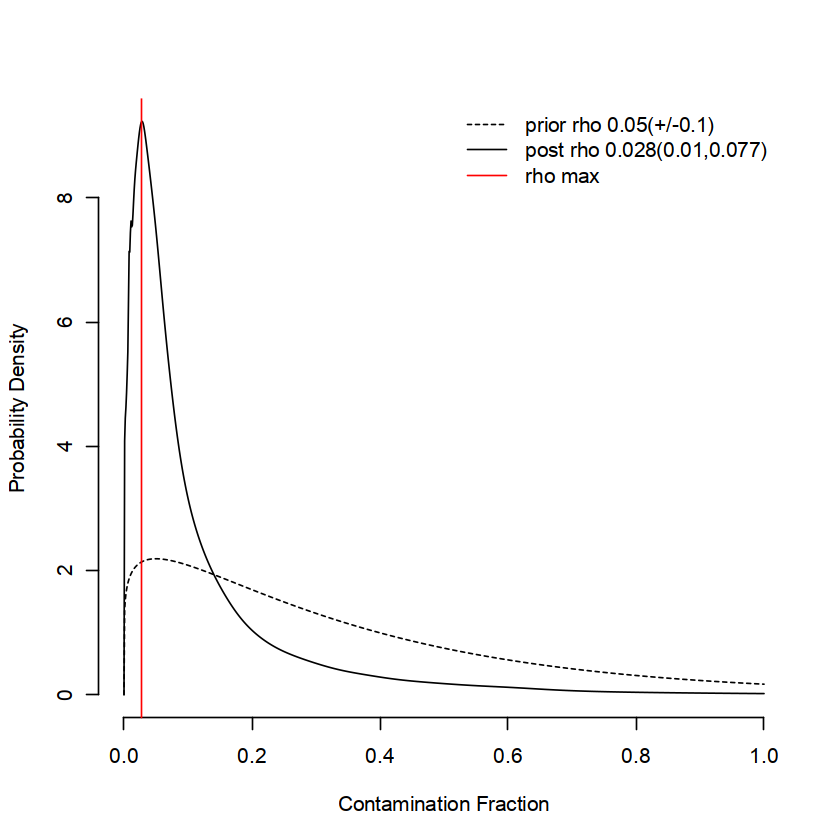

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 13 clusters to 10252 cells.



Running SoupX adjustment for: ./B217A 


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 8159
Number of edges: 302237

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9274
Number of communities: 20
Elapsed time: 0 seconds


19:18:23 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

19:18:23 Read 8159 rows and found 30 numeric columns

19:18:23 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

19:18:23 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:18:25 Writing NN index file to temp file /tmp/RtmpZZKdCc/file229825955f75e

19:18:25 Searching Annoy index using 1 thread, search_k = 3000

19:18:27 Annoy recall = 100%

19:18:28 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

19:18:30 Found 2 connected components, 
falling ba

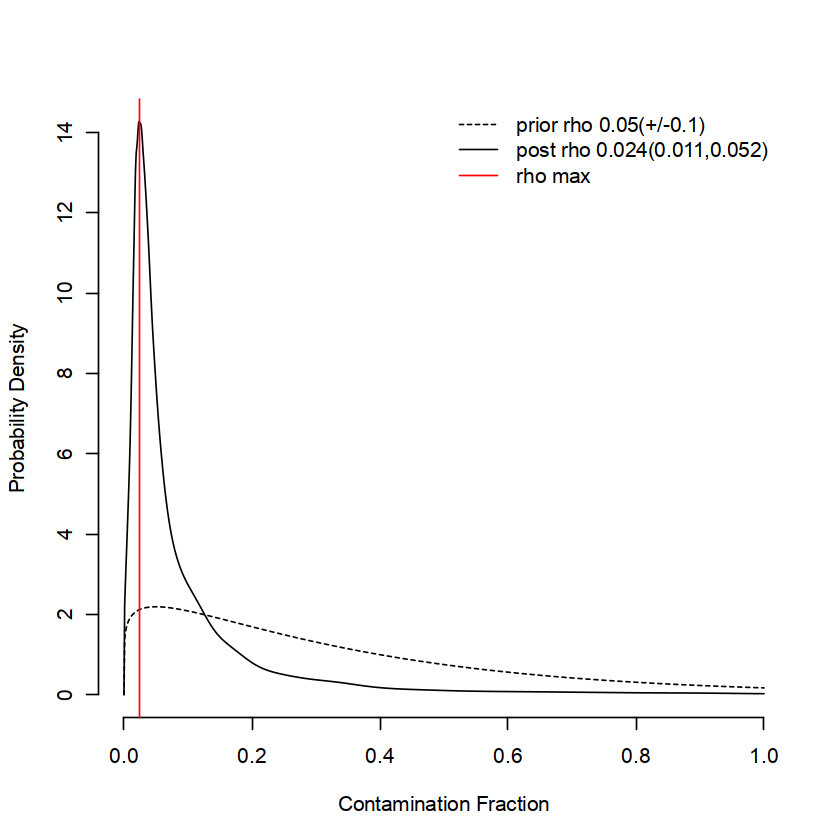

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 20 clusters to 8159 cells.



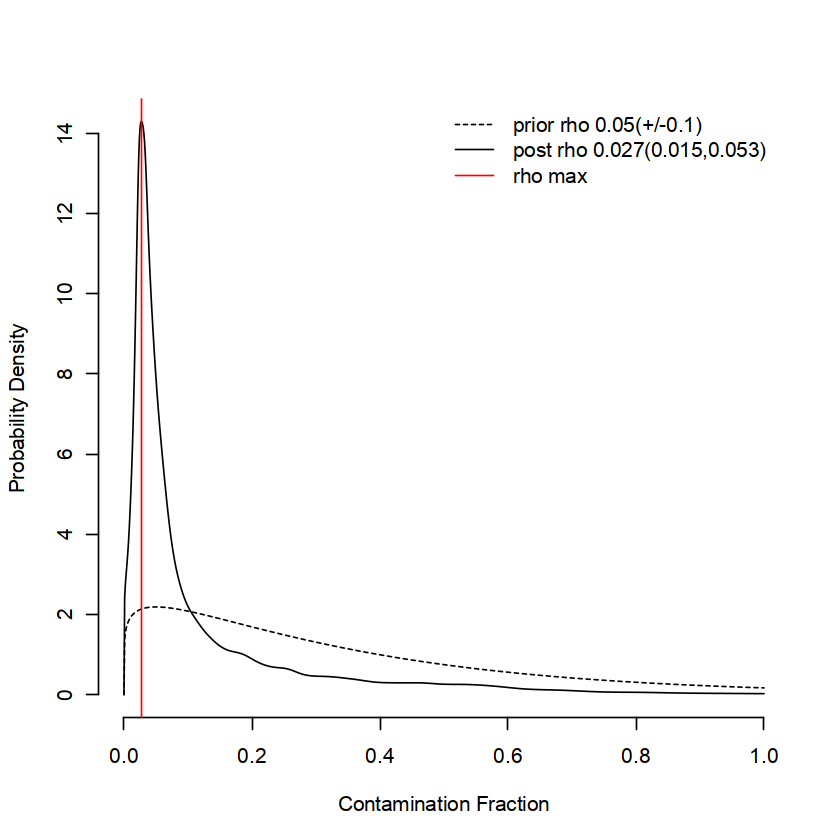

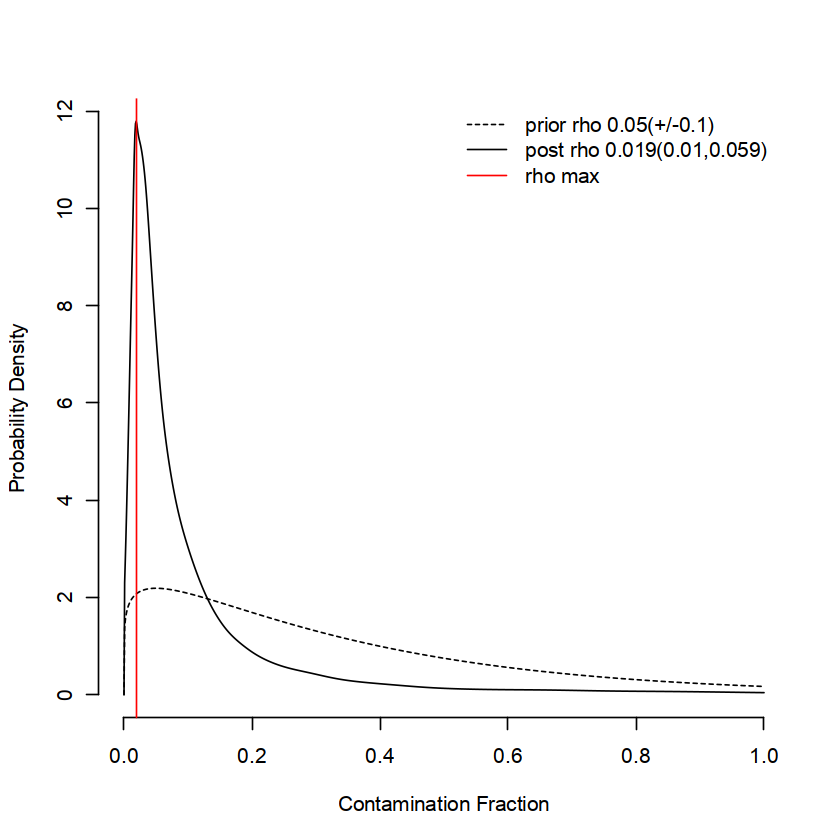

In [3]:
for (dir in subdirs) {
  toc_path <- file.path(dir, "filtered_feature_bc_matrix")
  tod_path <- file.path(dir, "raw_feature_bc_matrix")

  if (file.exists(toc_path) && file.exists(tod_path)) {
    cat("Running SoupX adjustment for:", dir, "\n")
    run_soupx(toc_path, tod_path, dir)
  } else {
    cat("Missing files in:", dir, "\n")
  }
}